# 📊 Notebook 01: Decomposição de Séries Temporais — Grupo B (SC)
**Disciplina**: Técnicas de IA Aplicadas a Sistemas de Energia  
**Programa**: Mestrado Profissional — IFSC  
**Aluno**: Dilsonei Rigotti  
**Professor**: Sérgio Ávila

---

## 🎯 Objetivo
Análise **exploratória e de contexto** da decomposição estatística (Tendência, Sazonalidade e Resíduos) do consumo elétrico (MWh) das três classes de baixa tensão do **Grupo B** em Santa Catarina — **Residencial, Comercial e Rural** — no período 1994–2026.

Este é o único notebook do projeto que olha para o Grupo B como um todo. Ele situa a classe Comercial entre as demais classes de baixa tensão e justifica o recorte adotado a partir daqui: **os notebooks 02–04 tratam exclusivamente do Subgrupo B3 Comercial**, o primeiro segmento da baixa tensão a ser impactado pela abertura do mercado prevista na Lei nº 15.269/2025.

> **Posição no fluxo:** este notebook é independente da trilha B3 (00 → 02 → 03 → 04). Ele não usa as saídas do notebook 00 e nenhum outro notebook depende dele.

## 1. Carregamento dos Dados

Base: `data/processed/sc_grupo_b_mensal.csv` — consumo mensal agregado por classe (Residencial, Comercial, Rural), 387 meses (jan/1994–mar/2026), na **versão revisada** após a validação de qualidade de dados descrita no README (seção *Qualidade de Dados*): valores negativos e `numero_uc = 0` com consumo positivo convertidos em ausentes antes da agregação.

> A classe Comercial aqui corresponde ao agregado do mercado Cativo da classe, e não apenas ao Subgrupo B3. Os valores não são diretamente comparáveis com a série `b3_cativo_mensal.csv` do notebook 00.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid")
%matplotlib inline


def localizar_raiz_projeto(marcador=".git"):
    for pasta in [Path.cwd(), *Path.cwd().parents]:
        if (pasta / marcador).exists():
            return pasta
    raise FileNotFoundError(f"Raiz do projeto (pasta com {marcador}) não encontrada a partir de {Path.cwd()}")


RAIZ_PROJETO = localizar_raiz_projeto()
DIR_TRATADOS = RAIZ_PROJETO / "data" / "processed"
DIR_PLOTS = RAIZ_PROJETO / "results" / "plots"
DIR_PLOTS.mkdir(parents=True, exist_ok=True)

CLASSES = ["Residencial", "Comercial", "Rural"]

In [2]:
df = pd.read_csv(DIR_TRATADOS / "sc_grupo_b_mensal.csv", parse_dates=["data"])

# Uma série mensal (frequência MS) por classe; lacunas pontuais interpoladas linearmente
series = {}
for classe in CLASSES:
    ts = df[df["classe"] == classe].set_index("data").sort_index()["consumo_mwh"].asfreq("MS")
    n_lacunas = int(ts.isna().sum())
    series[classe] = ts.interpolate(method="linear")
    print(f"{classe:12s}: {len(ts)} meses ({ts.index.min():%m/%Y} a {ts.index.max():%m/%Y}), {n_lacunas} lacunas interpoladas")

df.head()

Residencial : 387 meses (01/1994 a 03/2026), 0 lacunas interpoladas
Comercial   : 387 meses (01/1994 a 03/2026), 0 lacunas interpoladas
Rural       : 387 meses (01/1994 a 03/2026), 0 lacunas interpoladas


,classe,data,consumo_mwh,numero_uc,consumo_medio_kwh_uc
0,Comercial,1994-01-01,77720.983,0.0,NaN
1,Comercial,1994-02-01,77214.332,0.0,NaN
2,Comercial,1994-03-01,79659.559,0.0,NaN
3,Comercial,1994-04-01,77696.543,0.0,NaN
4,Comercial,1994-05-01,69609.934,0.0,NaN


## 2. Decomposição STL (Seasonal-Trend decomposition using LOESS)
A técnica STL decompõe a série temporal $Y_t$ em três componentes aditivos:
$$Y_t = T_t + S_t + R_t$$
onde $T_t$ é a tendência de longo prazo, $S_t$ é o padrão sazonal anual de 12 meses, e $R_t$ é o resíduo/ruído. Usa-se a versão robusta (`robust=True`), menos sensível a picos pontuais.

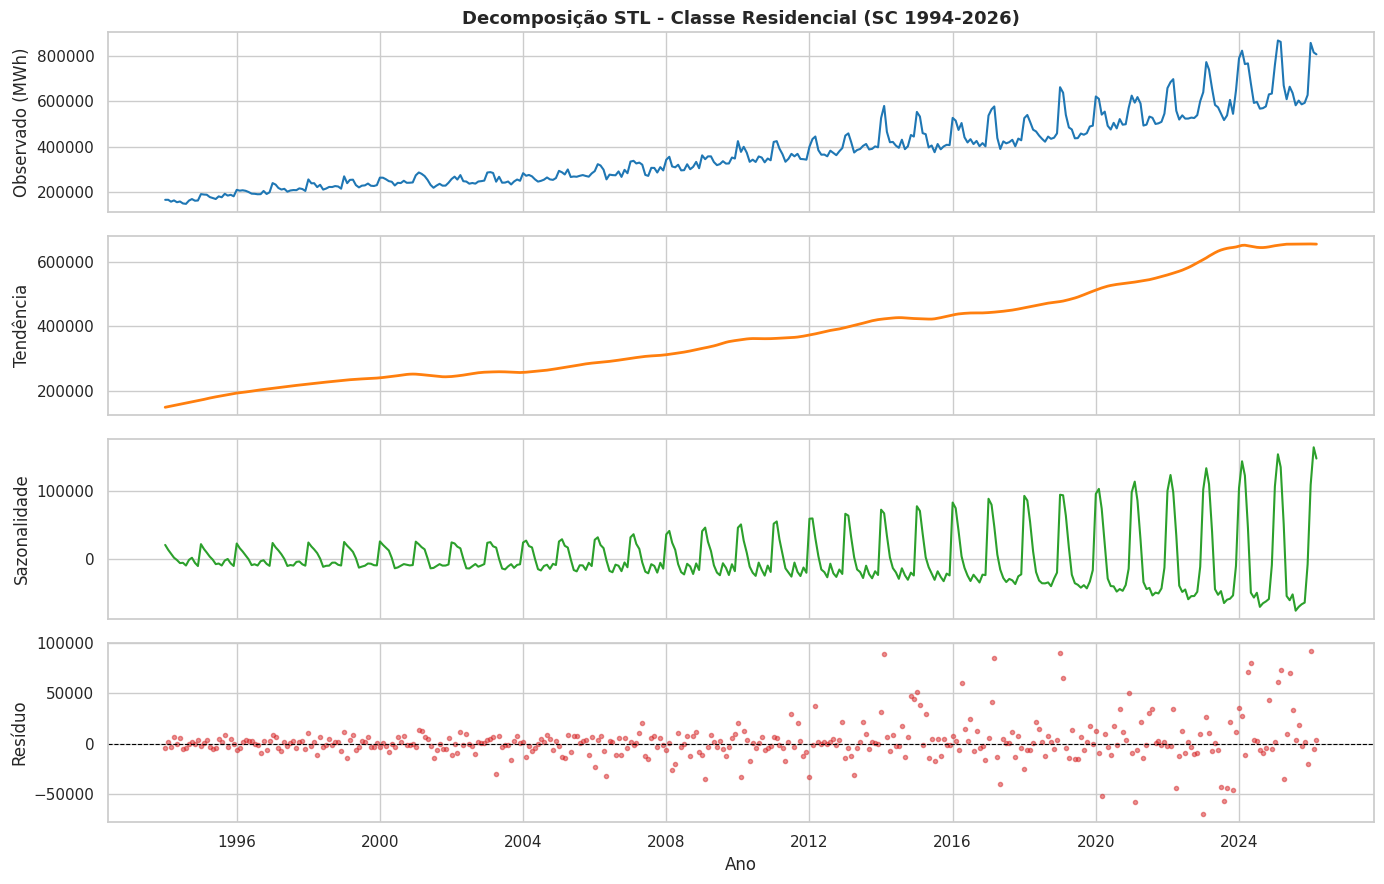

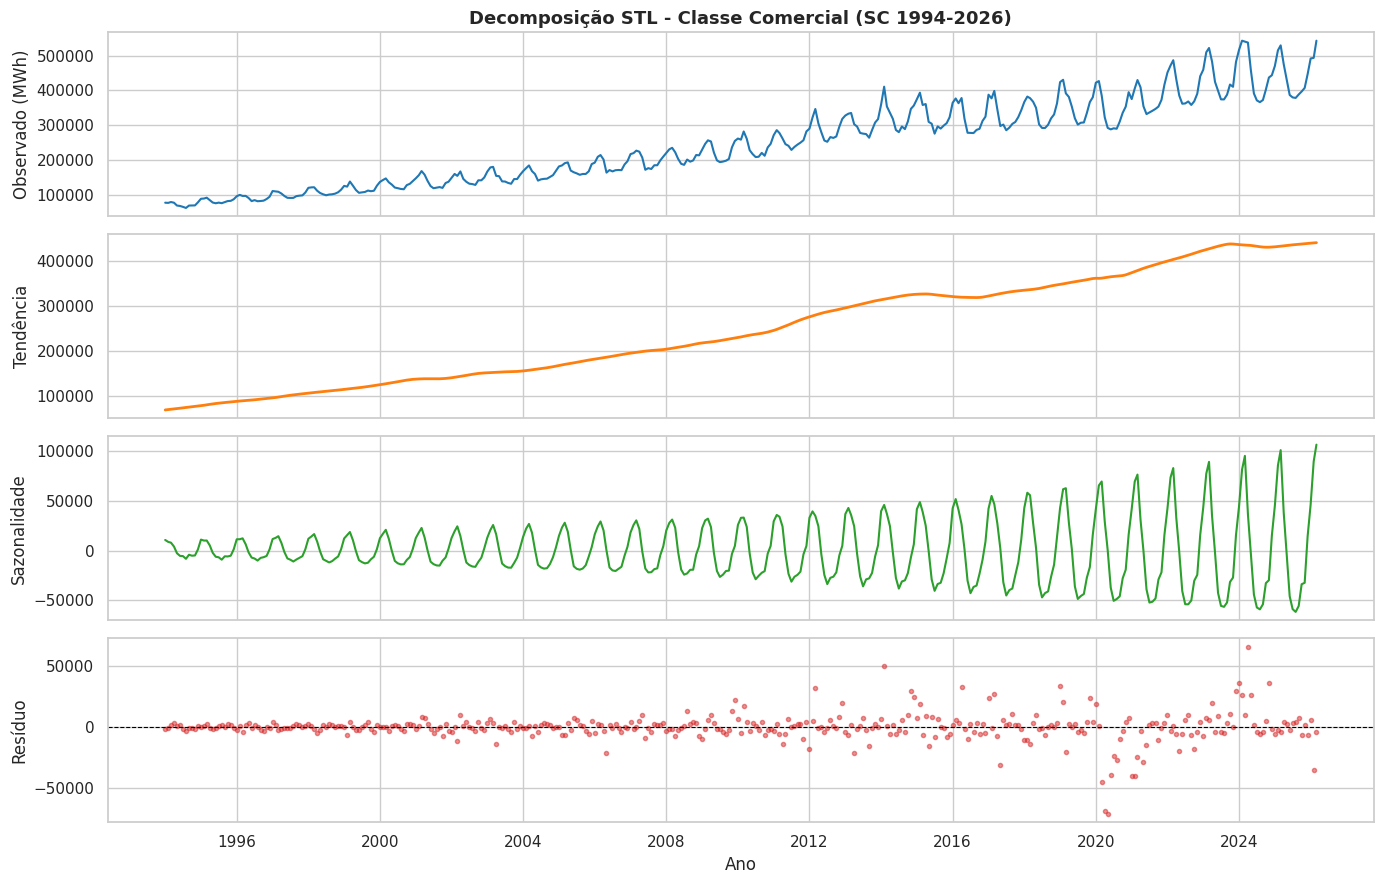

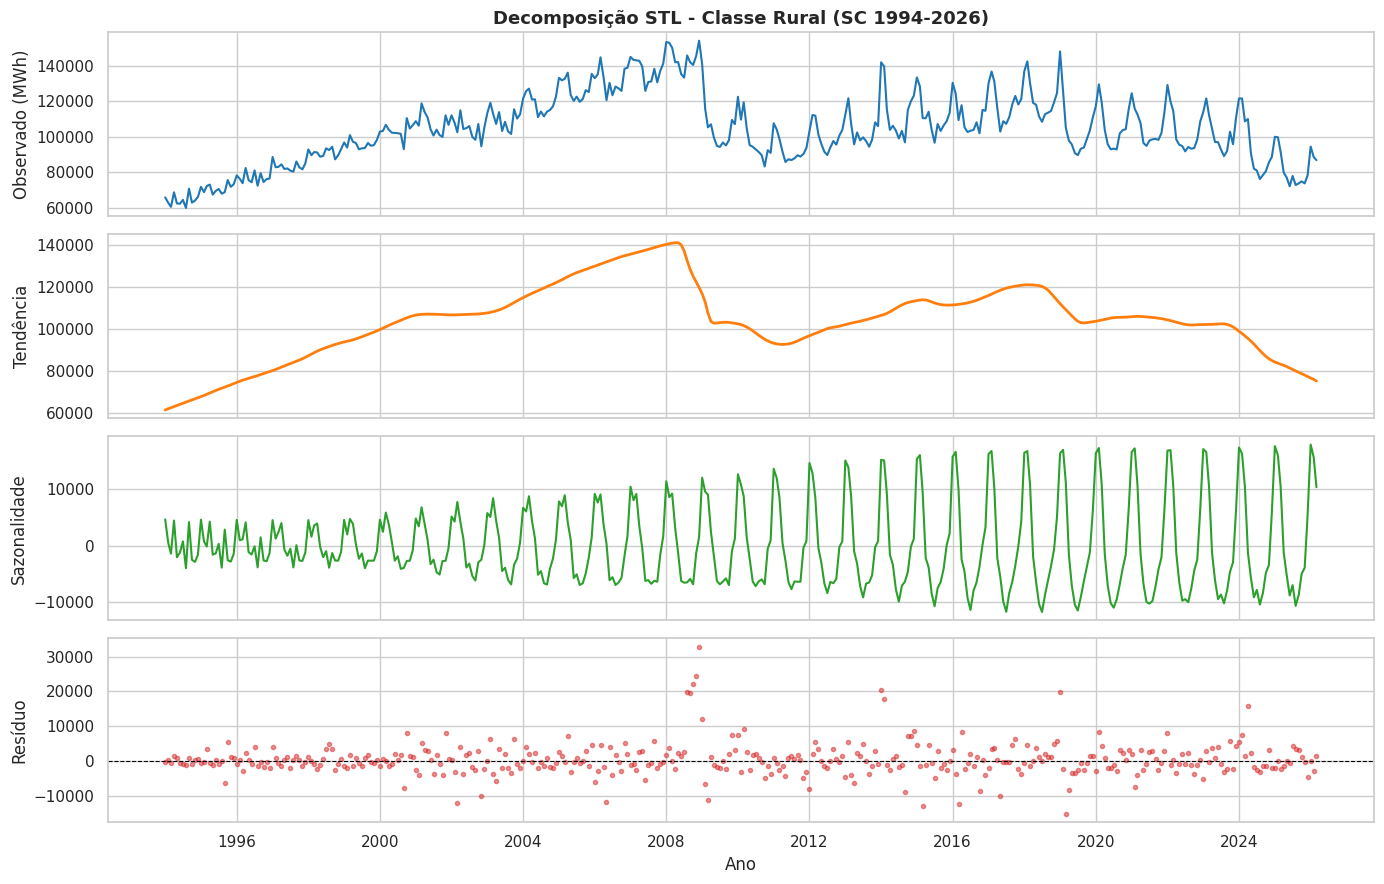

In [3]:
decomposicoes = {}

for classe, ts in series.items():
    res = STL(ts, period=12, seasonal=13, robust=True).fit()
    decomposicoes[classe] = res

    fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
    axes[0].plot(res.observed, color="#1f77b4", linewidth=1.5)
    axes[0].set_ylabel("Observado (MWh)")
    axes[0].set_title(f"Decomposição STL - Classe {classe} (SC 1994-2026)", fontsize=13, fontweight="bold")
    axes[1].plot(res.trend, color="#ff7f0e", linewidth=2)
    axes[1].set_ylabel("Tendência")
    axes[2].plot(res.seasonal, color="#2ca02c", linewidth=1.5)
    axes[2].set_ylabel("Sazonalidade")
    axes[3].plot(res.resid, color="#d62728", marker=".", linestyle="None", alpha=0.5)
    axes[3].axhline(0, color="black", linestyle="--", linewidth=0.8)
    axes[3].set_ylabel("Resíduo")
    axes[3].set_xlabel("Ano")
    plt.tight_layout()
    plt.savefig(DIR_PLOTS / f"01_stl_{classe.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 3. Autocorrelação (ACF) e Autocorrelação Parcial (PACF)
A análise de ACF e PACF auxilia na identificação da estrutura de dependência temporal e dos parâmetros de ordem $(p, d, q) \times (P, D, Q)_{12}$ de modelos da família ARIMA.

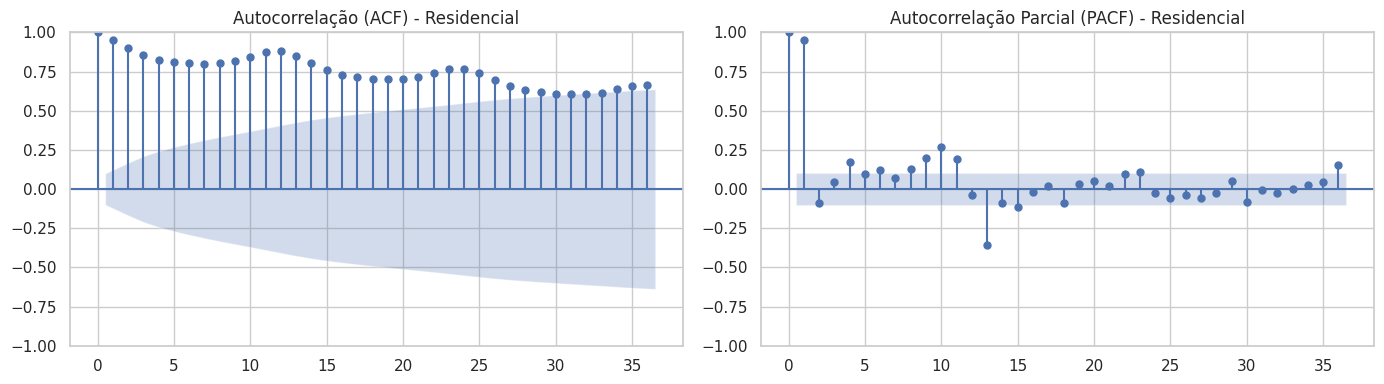

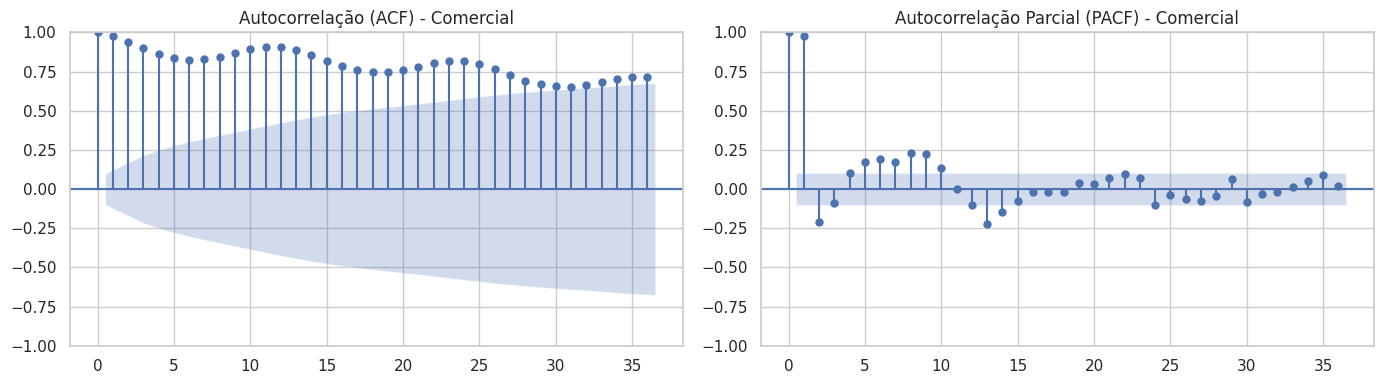

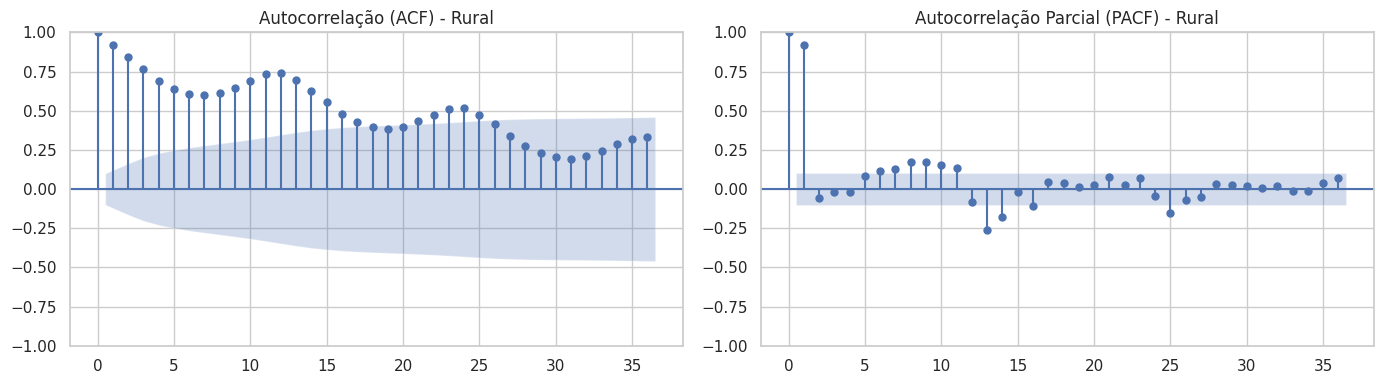

In [4]:
for classe, ts in series.items():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(ts, ax=ax1, lags=36, title=f"Autocorrelação (ACF) - {classe}")
    plot_pacf(ts, ax=ax2, lags=36, title=f"Autocorrelação Parcial (PACF) - {classe}")
    plt.tight_layout()
    plt.savefig(DIR_PLOTS / f"01_acf_pacf_{classe.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 4. Métricas de Força da Tendência e da Sazonalidade
Medidas de Wang, Smith & Hyndman (2006), calculadas a partir dos componentes STL:

$$F_T = \max\left(0,\ 1 - \frac{\operatorname{Var}(R_t)}{\operatorname{Var}(T_t + R_t)}\right) \qquad F_S = \max\left(0,\ 1 - \frac{\operatorname{Var}(R_t)}{\operatorname{Var}(S_t + R_t)}\right)$$

Valores próximos de 1 indicam componente forte. As métricas são exportadas para `data/processed/stl_metrics_grupo_b.json` (nome distinto do `stl_metrics_summary.json` do notebook 03, que se refere apenas à série B3).

In [5]:
def forca(componente, resid):
    return max(0.0, 1 - np.var(resid) / np.var(componente + resid))


metricas = {}
for classe, res in decomposicoes.items():
    metricas[classe] = {
        "forca_tendencia": round(forca(res.trend, res.resid), 4),
        "forca_sazonalidade": round(forca(res.seasonal, res.resid), 4),
        "consumo_medio_mwh": round(float(series[classe].mean()), 2),
        "consumo_max_mwh": round(float(series[classe].max()), 2),
        "consumo_min_mwh": round(float(series[classe].min()), 2),
    }

with open(DIR_TRATADOS / "stl_metrics_grupo_b.json", "w", encoding="utf-8") as f:
    json.dump(metricas, f, ensure_ascii=False, indent=2)

df_metricas = pd.DataFrame(metricas).T
df_metricas

,forca_tendencia,forca_sazonalidade,consumo_medio_mwh,consumo_max_mwh,consumo_min_mwh
Residencial,0.9824,0.8340,374587.60,866634.57,147992.54
Comercial,0.9897,0.8703,246373.29,543027.14,62667.34
Rural,0.9303,0.7022,104342.28,154303.63,59934.18


## 5. Leitura dos Resultados

| Classe | $F_T$ | $F_S$ |
|---|:---:|:---:|
| Residencial | 0,9824 | 0,8340 |
| Comercial | 0,9897 | 0,8703 |
| Rural | 0,9303 | 0,7022 |

**Tendência.** As três classes têm tendência muito forte ($F_T > 0{,}93$), mas com trajetórias distintas. Residencial e Comercial crescem de forma contínua ao longo de todo o período; na Comercial, a tendência passa de cerca de 70 mil para cerca de 440 mil MWh/mês, com um patamar em 2015–2017. A classe Rural cresce até 2008, sofre uma **queda abrupta em 2008–2009** (de cerca de 140 mil para 103 mil MWh/mês) e volta a cair a partir de 2024. Uma ruptura tão brusca sugere mudança de classificação de consumidores ou de critério da fonte, e não variação de consumo; é tratada aqui como possível quebra estrutural da base, não investigada neste trabalho.

**Sazonalidade.** A classe **Comercial tem a sazonalidade mais marcada do Grupo B** ($F_S \approx 0{,}87$), com picos no verão (refrigeração no varejo e turismo). A amplitude do componente sazonal **cresce com o nível da série** (de cerca de ±10 mil para ±100 mil MWh na Comercial), comportamento típico de sazonalidade multiplicativa; como a STL aplicada é aditiva, parte desse efeito pode aparecer no resíduo. Uma alternativa seria decompor o logaritmo do consumo.

**Resíduos.** Os maiores desvios negativos da classe Comercial ocorrem em **abr–mai/2020**, coincidindo com as restrições ao comércio na pandemia de COVID-19. Nas classes Residencial e Comercial, a dispersão dos resíduos aumenta após 2014.

**Autocorrelação.** A ACF decai lentamente, com picos nos lags 12, 24 e 36 (tendência forte e sazonalidade anual); na PACF, o lag 1 é próximo de 0,97 e os lags 12–13 são significativos. Modelos da família ARIMA exigiriam diferenciação simples e sazonal ($d = 1$, $D = 1$).

### Por que o recorte no B3 Comercial

A classe Comercial combina a **tendência de crescimento mais forte** e a **sazonalidade mais intensa** do Grupo B. Para um consumidor que migra ao Ambiente de Contratação Livre, essas duas características são justamente as que determinam o risco contratual: o crescimento define o volume a contratar e a sazonalidade define a necessidade de sazonalização e modulação dos contratos, com exposição ao PLD nos meses de pico. Somado ao fato de o Subgrupo B3 ser o primeiro segmento da baixa tensão a ser impactado pela abertura do mercado, isso motiva o foco exclusivo no **B3 Comercial** nos notebooks seguintes:

- **00** — tratamento da base e construção da série B3 Cativo;
- **02 / 03** — modelagem preditiva do consumo B3 (Holt-Winters, LSTM, Gradient Boosting);
- **04** — análise econômica da migração do B3 para o mercado livre.